# Fase 3 — Análisis individual de jugador

Módulos 6–7 del temario: heat maps individuales y radios de acción.

Sigue usando `data/processed/events_ejemplo.pkl` generado en la Fase 1.

In [1]:
import pandas as pd
from mplsoccer import Pitch

events = pd.read_pickle("../data/processed/events_ejemplo.pkl")
print("Jugadores disponibles:")
print(events["player"].dropna().unique())

Jugadores disponibles:
<StringArray>
[      'Neymar da Silva Santos Junior',                  'Fernando Luiz Roza',
           'Philippe Coutinho Correia',      'Marcelo Vieira da Silva Júnior',
         'João Miranda de Souza Filho',            'Thiago Emiliano da Silva',
               'Fágner Conserva Lemos',                      'Jan Vertonghen',
                     'Vincent Kompany',                   'Toby Alderweireld',
               'Alisson Ramsés Becker',    'José Paulo Bezzera Maciel Júnior',
                'Romelu Lukaku Menama',                      'Thomas Meunier',
          'Marouane Fellaini-Bakkioui',                         'Axel Witsel',
           'Gabriel Fernando de Jesus',                    'Thibaut Courtois',
                         'Eden Hazard',                     'Kevin De Bruyne',
                        'Nacer Chadli',             'Willian Borges da Silva',
 'Roberto Firmino Barbosa de Oliveira',              'Douglas Costa de Souza',
   'Renato Soar

In [4]:
jugador = "Renato Soares de Oliveira Augusto"  # elige un nombre de la lista anterior

acciones = events[events["player"] == jugador].dropna(subset=["location"]).copy()
acciones[["x", "y"]] = pd.DataFrame(acciones["location"].tolist(), index=acciones.index)
acciones.shape

(39, 82)

## Heat map individual

Text(0.5, 1.0, 'Heat map individual — Renato Soares de Oliveira Augusto')

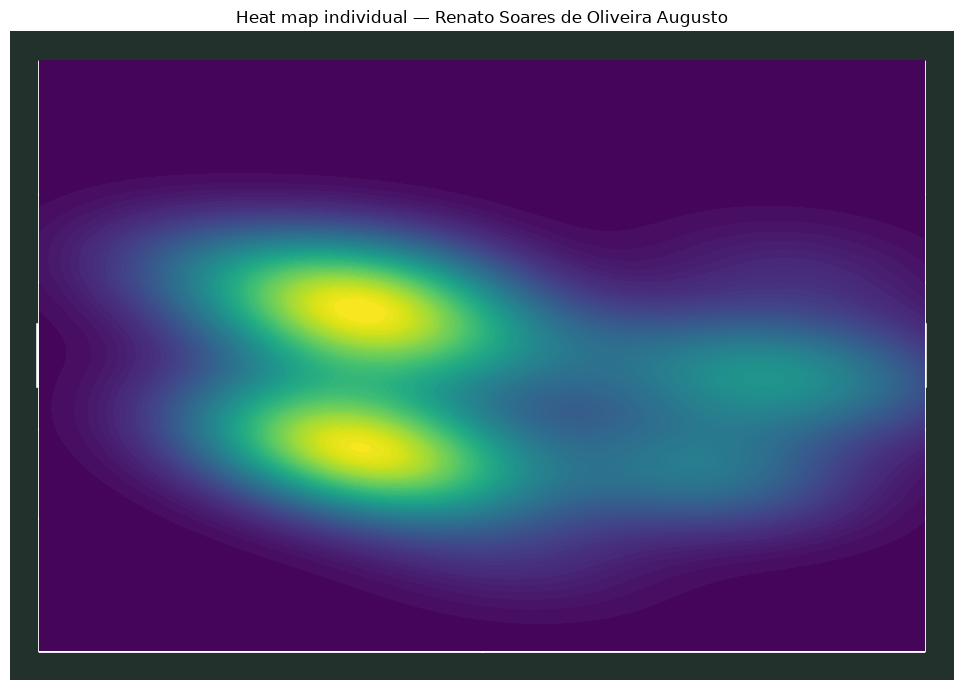

In [5]:
pitch = Pitch(pitch_type="statsbomb", pitch_color="#22312b", line_color="white")
fig, ax = pitch.draw(figsize=(10, 7))
pitch.kdeplot(acciones.x, acciones.y, ax=ax, fill=True, levels=100, cmap="viridis", thresh=0)
ax.set_title(f"Heat map individual — {jugador}")

## Radio de acción

Una forma simple: dibujar una elipse de desviación estándar (1 o 2 sigma)
sobre las acciones del jugador, centrada en su posición media. Es una
aproximación visual de "dónde vive" un jugador en el campo.

Text(0.5, 1.0, 'Radio de acción (±1 sigma) — Renato Soares de Oliveira Augusto')

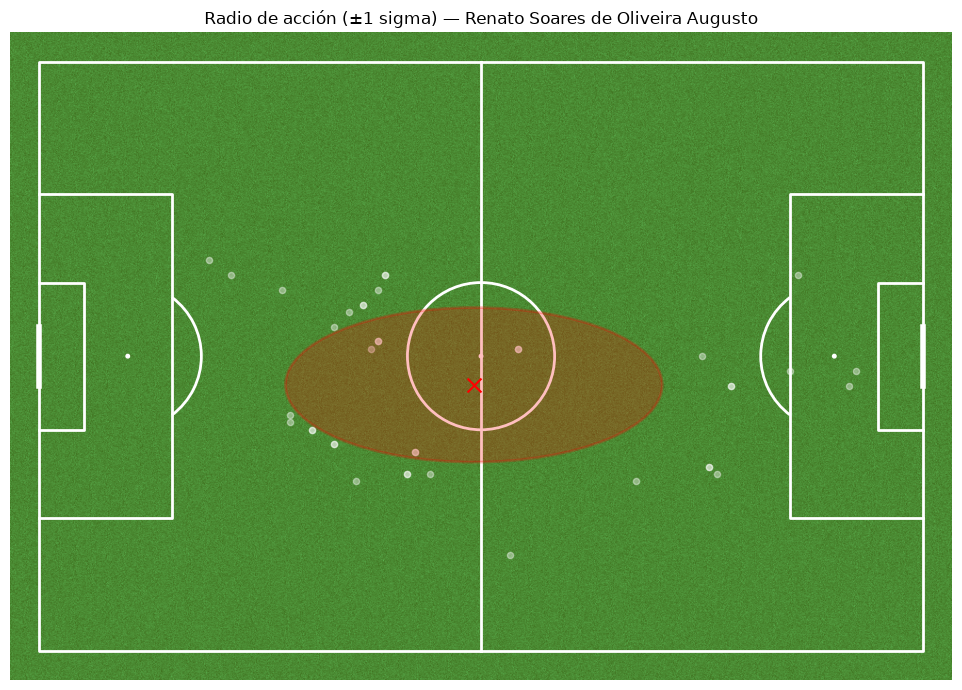

In [6]:
import numpy as np
from matplotlib.patches import Ellipse

mean_x, mean_y = acciones.x.mean(), acciones.y.mean()
std_x, std_y = acciones.x.std(), acciones.y.std()

pitch = Pitch(pitch_type="statsbomb", pitch_color="grass", line_color="white")
fig, ax = pitch.draw(figsize=(10, 7))
pitch.scatter(acciones.x, acciones.y, ax=ax, color="white", alpha=0.4, s=20)

ellipse = Ellipse(
    (mean_x, mean_y), width=std_x * 2, height=std_y * 2,
    edgecolor="red", facecolor="red", alpha=0.25, lw=2,
)
ax.add_patch(ellipse)
pitch.scatter(mean_x, mean_y, ax=ax, color="red", marker="x", s=100)
ax.set_title(f"Radio de acción (±1 sigma) — {jugador}")

## Nota

El temario original habla de "comportamientos específicos y estadísticas
concretas" por jugador para el radio de acción — en la práctica cada curso
define su propia métrica (elipse de desviación estándar, convex hull de
acciones, o percentil de distancia al centroide). La elipse de arriba es la
más simple y un buen punto de partida; el convex hull (área mínima que
contiene todas las acciones) es una variante más estricta que puedes probar
con `scipy.spatial.ConvexHull`.

Siguiente notebook: `04_metricas_avanzadas_radar_beeswarm.ipynb`.